# Feature Engineering and EDA of Derived Features

In this third notebook of the v4 series, the **feature engineering** stage is executed and audited. Deterministic transformations are applied by `build_preprocessing_pipeline`, and the descriptive utility of the engineered features is examined before supervised feature selection is performed during modeling.

To avoid confusing historical growth of the operation with calendar or climate effects, the demand distributions are evaluated on the **detrended index** produced by `src.seasonal.demand_index_moving_average`. Hourly demand is divided by a moving baseline centered on 365 days, estimated from daily averages. Thus, a multiplicative reading around 1 is preserved, while the structural level change is removed from the comparison.

The analysis is retrospective. Because the centered window uses future observations, the index is not treated as an operational feature. No causal effects are assigned to the observed differences: hour, season, precipitation, and thermal variables remain interrelated.


In [2]:
import logging
import sys
from pathlib import Path
import warnings

PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import read_data
from src.feature_engineering import build_preprocessing_pipeline
from src.plotting import set_graph_parameters
from src.i18n import make_lang
from src import feature_eda as fe

warnings.filterwarnings('ignore', category=FutureWarning)
logging.getLogger('matplotlib.category').setLevel(logging.WARNING)

lang = make_lang('en')          # PT canônico — passthrough, sem chamadas de rede
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

TARGET = 'Rented Bike Count'
INDEX = 'Demand_Index'

raw = read_data()
df = build_preprocessing_pipeline().fit_transform(raw.copy())

msg = lang({'rows': 'Linhas', 'raw_cols': 'Colunas brutas',
            'eng_cols': 'colunas após a engenharia', 'period': 'Período', 'to': 'a'})
print(f'{msg["rows"]}: {len(df):,}')
print(f'{msg["raw_cols"]}: {raw.shape[1]} | {msg["eng_cols"]}: {df.shape[1]}')
date_fmt = lang({'date_fmt': '%d/%m/%Y %H:%M'})['date_fmt']
print(f'{msg["period"]}: {format(df["Date"].min(), date_fmt)} {msg["to"]} '
      f'{format(df["Date"].max(), date_fmt)}')


Rows: 81,018
Raw columns: 17 | columns after feature engineering: 27
Period: 09/19/2015 00:00 to 12/31/2024 23:00


## 1. Audit of Features Created by the Pipeline

Calendar, daypart, operating-condition, and meteorological-band features are derived. The `Date` column is preserved as a temporal index; `Month` and `Year` are extracted from the timestamp; and categorical representations retain the labels defined by the pipeline contract.

In this EDA, missing values are not globally imputed. Statistics are calculated from available cases, and missingness is explicitly reported in the counts. During modeling, imputation must continue to be fitted only on the training subset of each temporal split.

The previous definition of `Rush_Hour` was also audited. `Functioning Day` was being used as if it indicated a business day, which allowed weekends to be marked as peak hours. The rule was corrected to require simultaneously weekday, active operation, and absence of holiday. Additionally, `Rush_Period` was created, preserving morning and afternoon/night peaks separately.


In [3]:
inventory = fe.created_features_inventory(df, lang=lang)
display(inventory)

missing = fe.missing_features_summary(df, lang=lang)
missing_labels = lang({'percentage': 'Percentual'})
display(missing.style.format({missing_labels['percentage']: '{:.2f}%'}))

audit = fe.rush_hour_audit(df)
msg = lang({
    'legacy': 'Fins de semana classificados como pico pela regra anterior',
    'revised': 'Fins de semana classificados como pico pela regra revisada',
})
print(f'{msg["legacy"]}: {audit["legacy_weekend"]:,}')
print(f'{msg["revised"]}: {audit["revised_weekend"]:,}')


,Variable,Present,Type,Distinct values,Missing
0,Date,True,datetime64[ns],81018,0
1,Time_Period,True,category,4,0
2,Weekday,True,category,7,0
3,DayNumberOnWeek,True,int32,7,0
4,WeekStatus,True,category,2,0
5,Rush_Hour,True,category,2,0
6,Rush_Period,True,category,3,0
7,Rainfall Cat,True,category,4,0
8,Snowfall Cat,True,category,4,0
9,Sunshine Cat,True,category,4,0


,Missing,Percentage
Cloud Cover (oktas),5482,6.77%
Cloud Cover Cat,5482,6.77%
Wind speed (m/s),123,0.15%
Ground Temp(C),32,0.04%
Temperature(C),5,0.01%
Humidity(%),4,0.00%
Dew point temperature(C),2,0.00%
Visibility (10m),1,0.00%


Weekend rows classified as peak periods by the previous rule: 6,487
Weekend rows classified as peak periods by the revised rule: 0


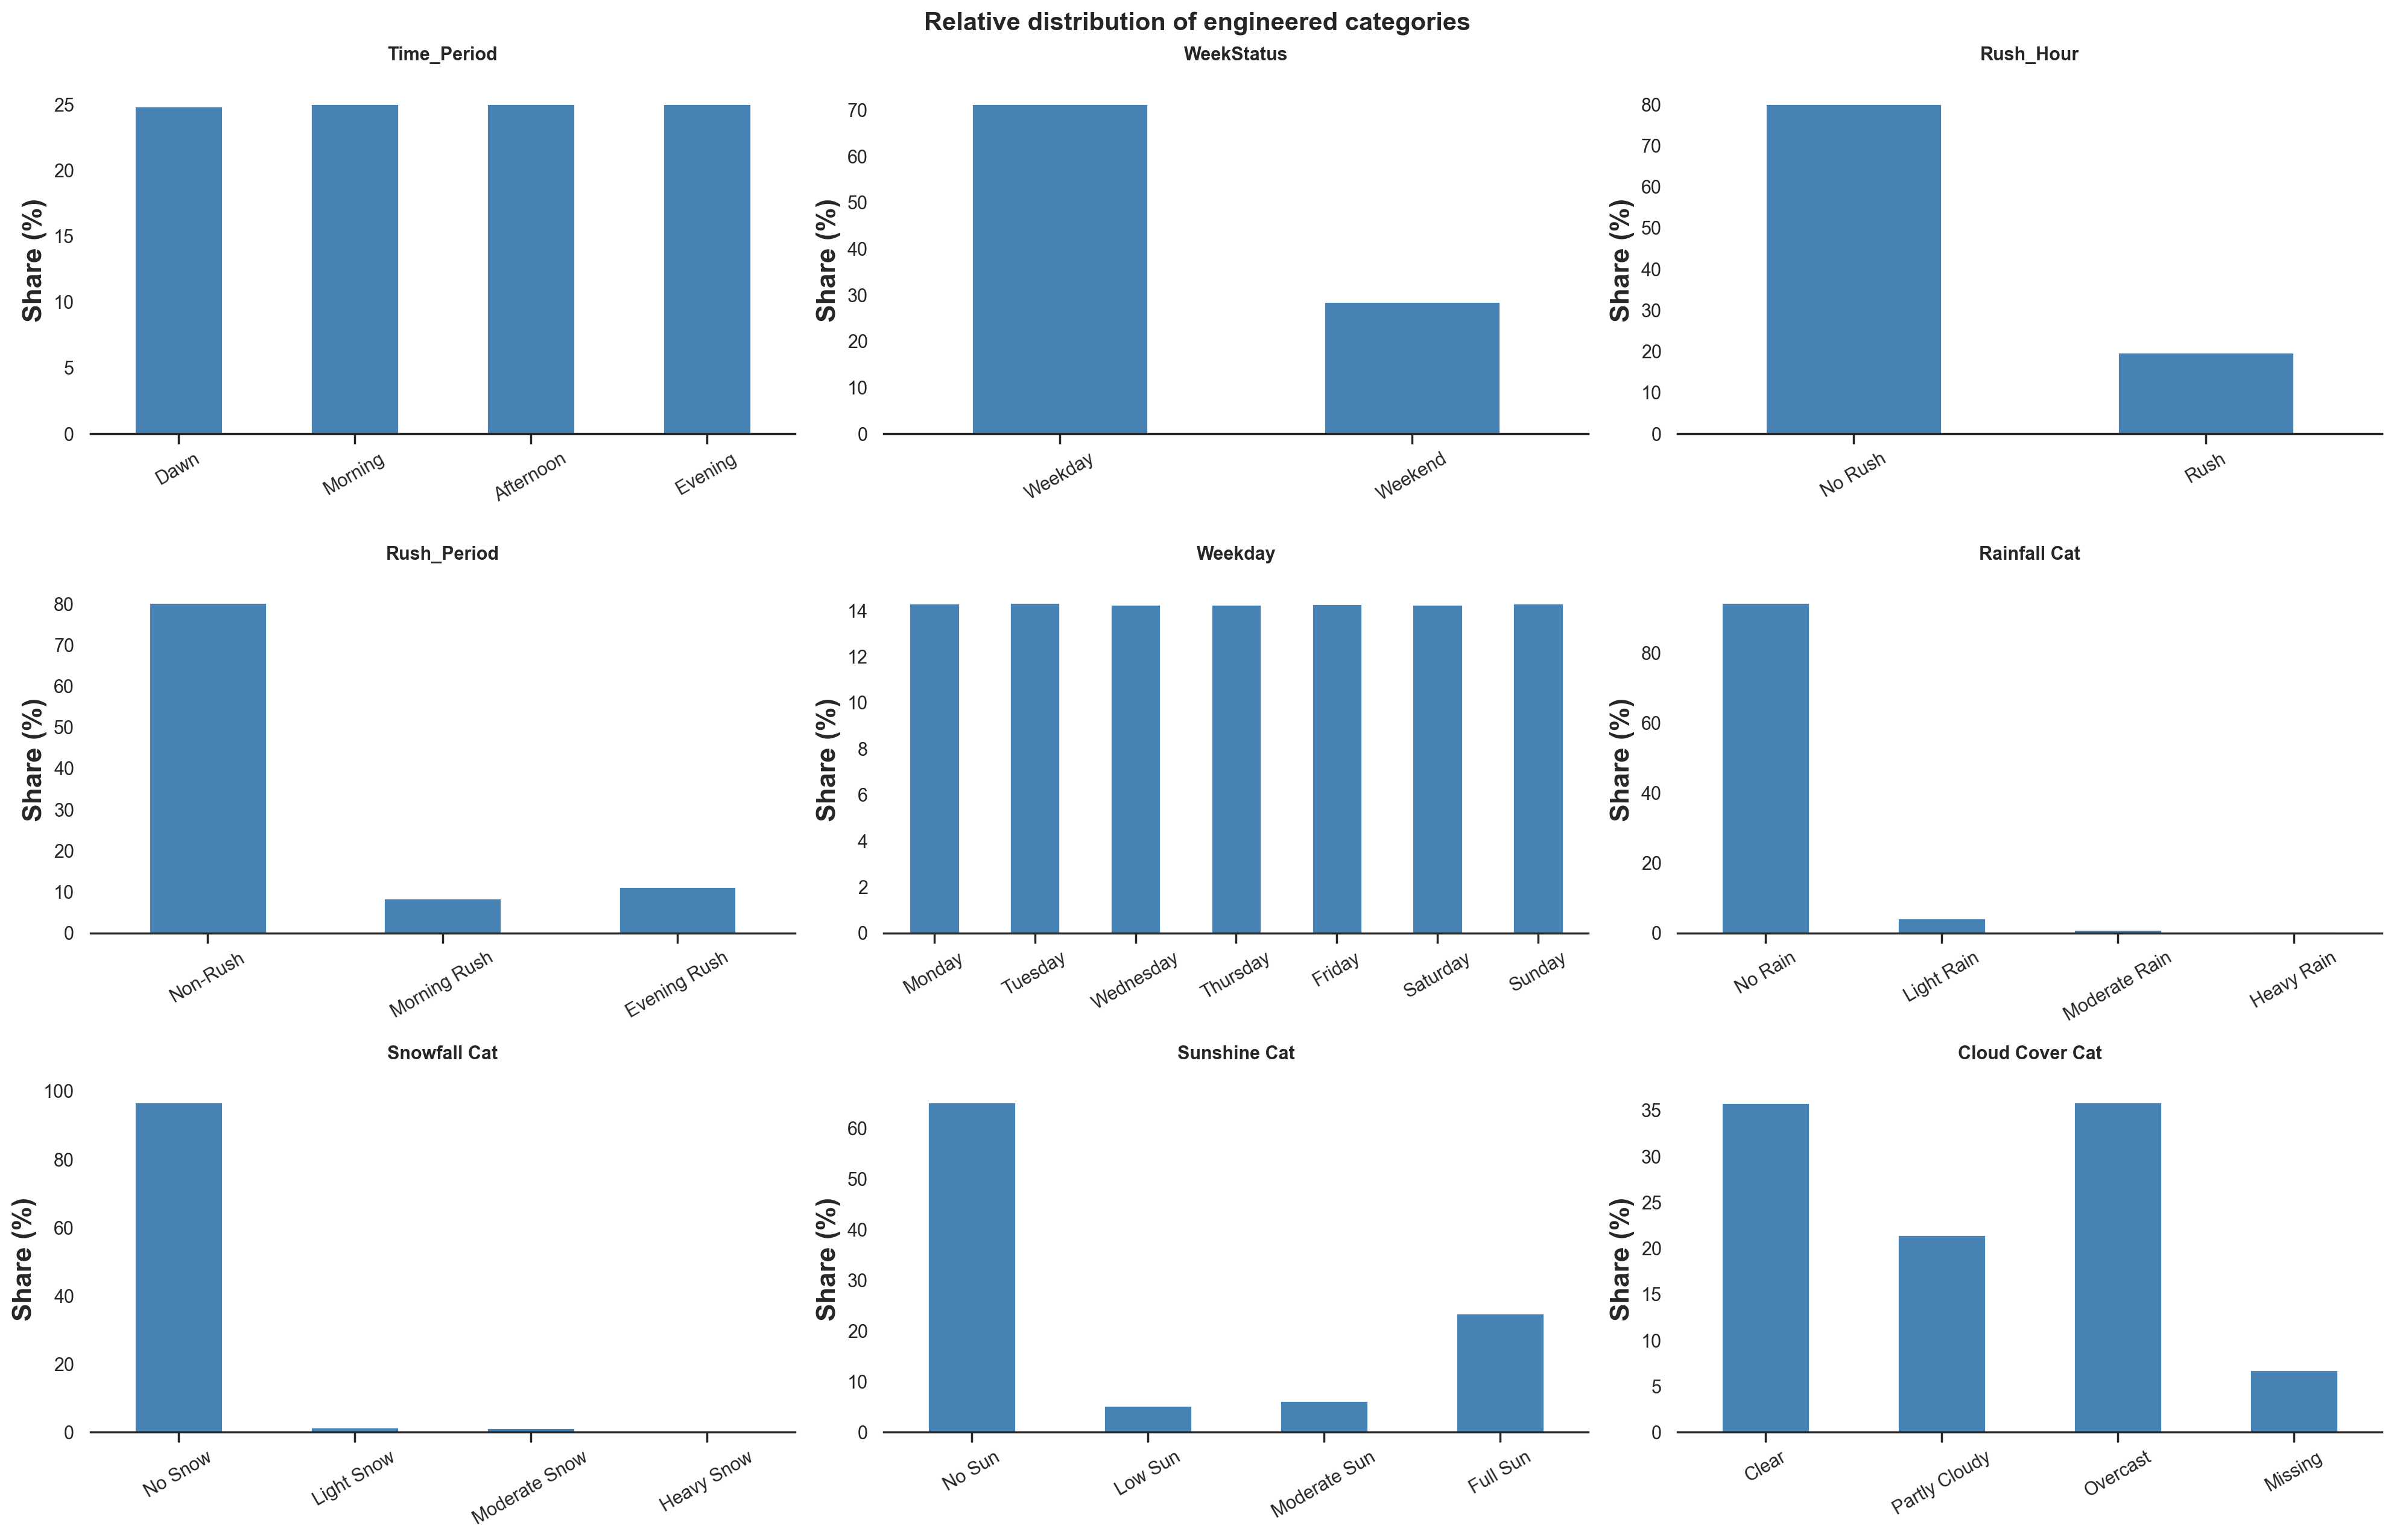

In [4]:
fig, axes = fe.plot_category_distribution(df, lang=lang)
plt.show()


>### Insight
>
> Thirteen derived variables have been confirmed. The largest absence was concentrated in `Cloud Cover (oktas)` and, consequently, in `Cloud Cover Cat`; this absence was kept visible at this stage, instead of being filled with a calculated statistic over the entire period.
>
> The peak-rule audit showed that 6,487 weekend rows would have been classified as `Rush` by the previous implementation. After requiring `WeekStatus == 'Weekday'`, no weekend remained in that class. The new `Rush_Period` was integrated into the optimizer's categorical search space so that the difference between morning and afternoon/evening peaks can be evaluated by the selectors within temporal validation.


## 2. Descriptive Target: Detrended Demand Index

Raw demand is converted into the multiplicative index $I_t = Y_t / \widehat{T}_t$, where $\widehat{T}_t$ is the **centered** moving average of daily demand over a 365-day window. Daily aggregation prevents the window from being misinterpreted as 365 hours, while the annual span tracks the structural level without removing all seasonal variation.

The construction follows the logic of ratio-to-moving-average decomposition. Months in 2020 whose mean demand fell below 60% of the geometric mean for the corresponding months of 2019 and 2021 are excluded only from baseline estimation. Their observations remain in the index, preventing the anomalous regime from artificially lowering the reference against which that same regime is compared.

The geometric mean was adopted because demand growth occurs predominantly in a multiplicative manner. Thus, $(\sqrt{Y_{2019,m}Y_{2021,m}})$ represents the interpolation of the expected level for 2020 on the logarithmic scale. Unlike the arithmetic mean, this reference is not excessively displaced by the higher level of 2021.

For example, between values of 100 and 400, a trajectory with constant proportional growth would have 200 as its midpoint, the value returned by the geometric mean; the arithmetic mean would return 250.

The edges with insufficient days for the moving average are discarded from the EDA. The original demand is preserved in `Rented Bike Count`, while the index is stored separately in `Demand_Index`; thus, the ambiguity of overwriting the raw target with a transformed measure is avoided.


In [5]:
mv, demand_index, anomaly_mask = fe.detrended_index_frame(df, TARGET, INDEX)
display(fe.detrend_diagnostics(df, mv, demand_index, anomaly_mask, TARGET, INDEX, lang=lang))


,Diagnostic
Anomalous months of 2020,"5, 6, 7, 8, 9, 10, 11, 12"
Rows retained,"75,304 (92.9%)"
Mean growth 2015→2024,106.8×
Mean index,0.972
Index median,0.717
Range of monthly means,1.108


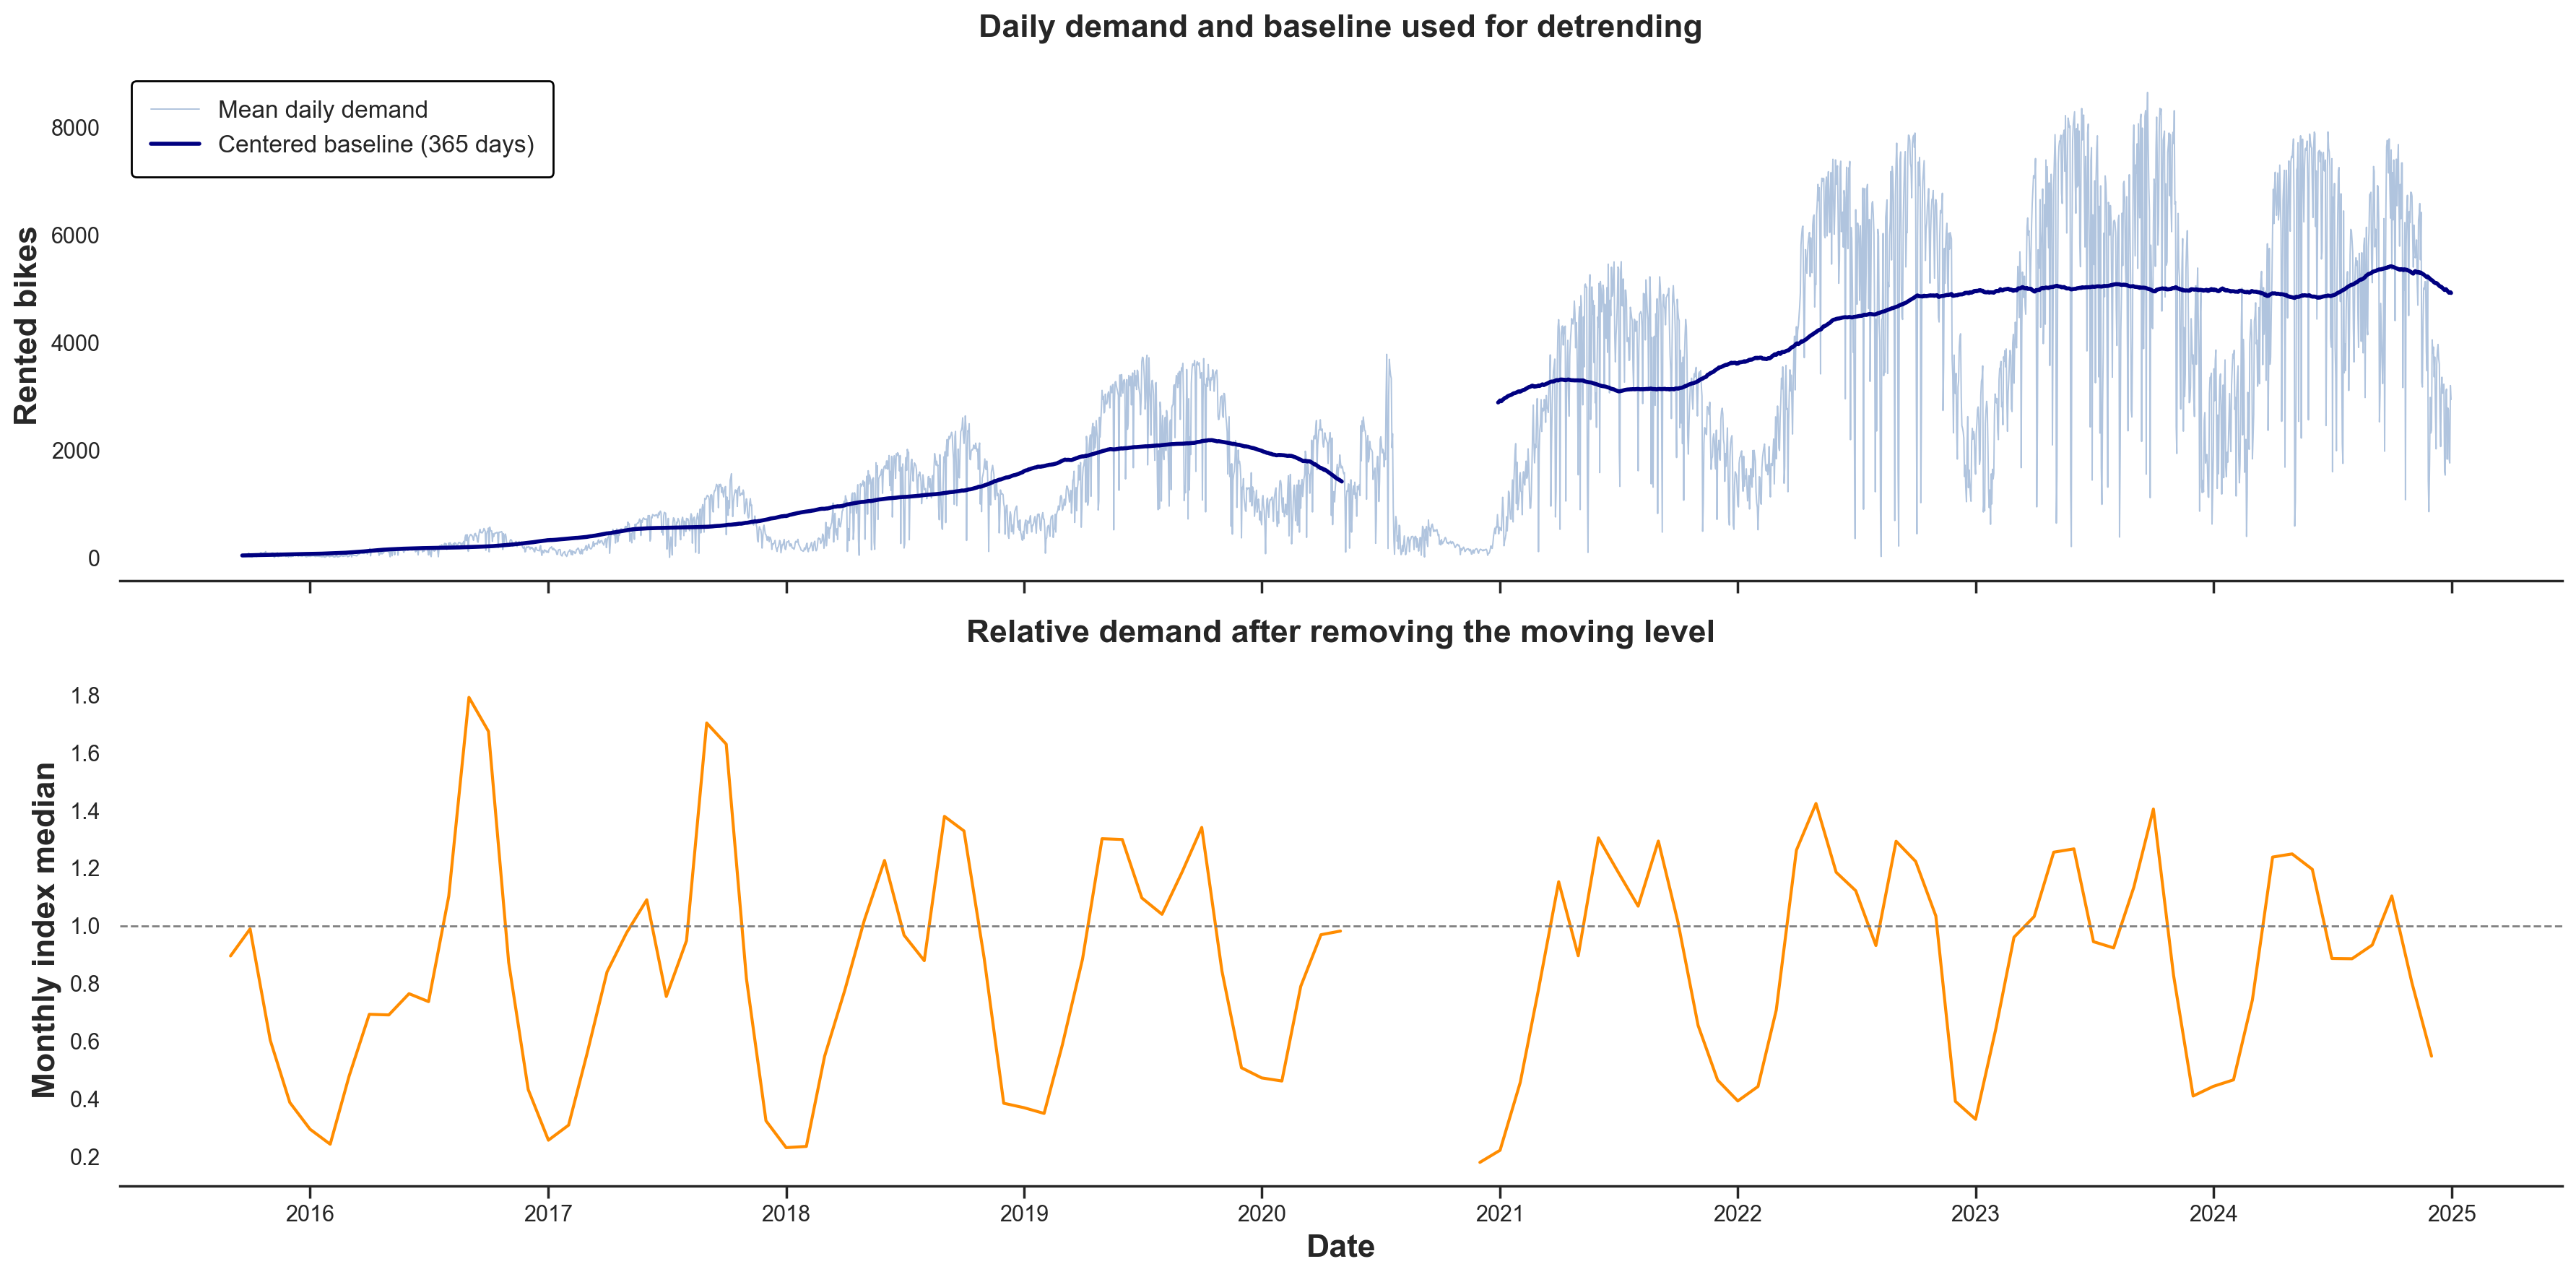

In [6]:
fig, axes = fe.plot_detrend_baseline(df, mv, anomaly_mask, TARGET, INDEX, lang=lang)
plt.show()


>### Insight
>
> Mean demand grew by approximately 106.8 times between 2015 and 2024, while 92.9% of the rows remained available after the centered window's minimum-data requirement. Therefore, direct comparisons of raw counts would be dominated by the observation year rather than only by the category being examined.
>
> The range of 1.11 across monthly mean index values showed that seasonality was not eliminated by the annual baseline. The index was retained exclusively as a retrospective descriptive target because its centered moving average incorporates information later than the time being analyzed and would cause leakage if supplied to the operational estimator.


## 3. Relative Demand by Engineered Feature

The distributions of `Demand_Index` are compared across the levels of the nine engineered categorical features. The reference line at 1 represents the moving baseline: values above it indicate demand above the local reference, whereas values below it indicate demand below that reference.

To keep the common scale readable, observations classified as *fliers* by the boxplot are not drawn, but no observation is removed from the calculations. Medians, quartiles, and group sizes are calculated separately so that large differences supported by only a few occurrences can be distinguished from recurring patterns.


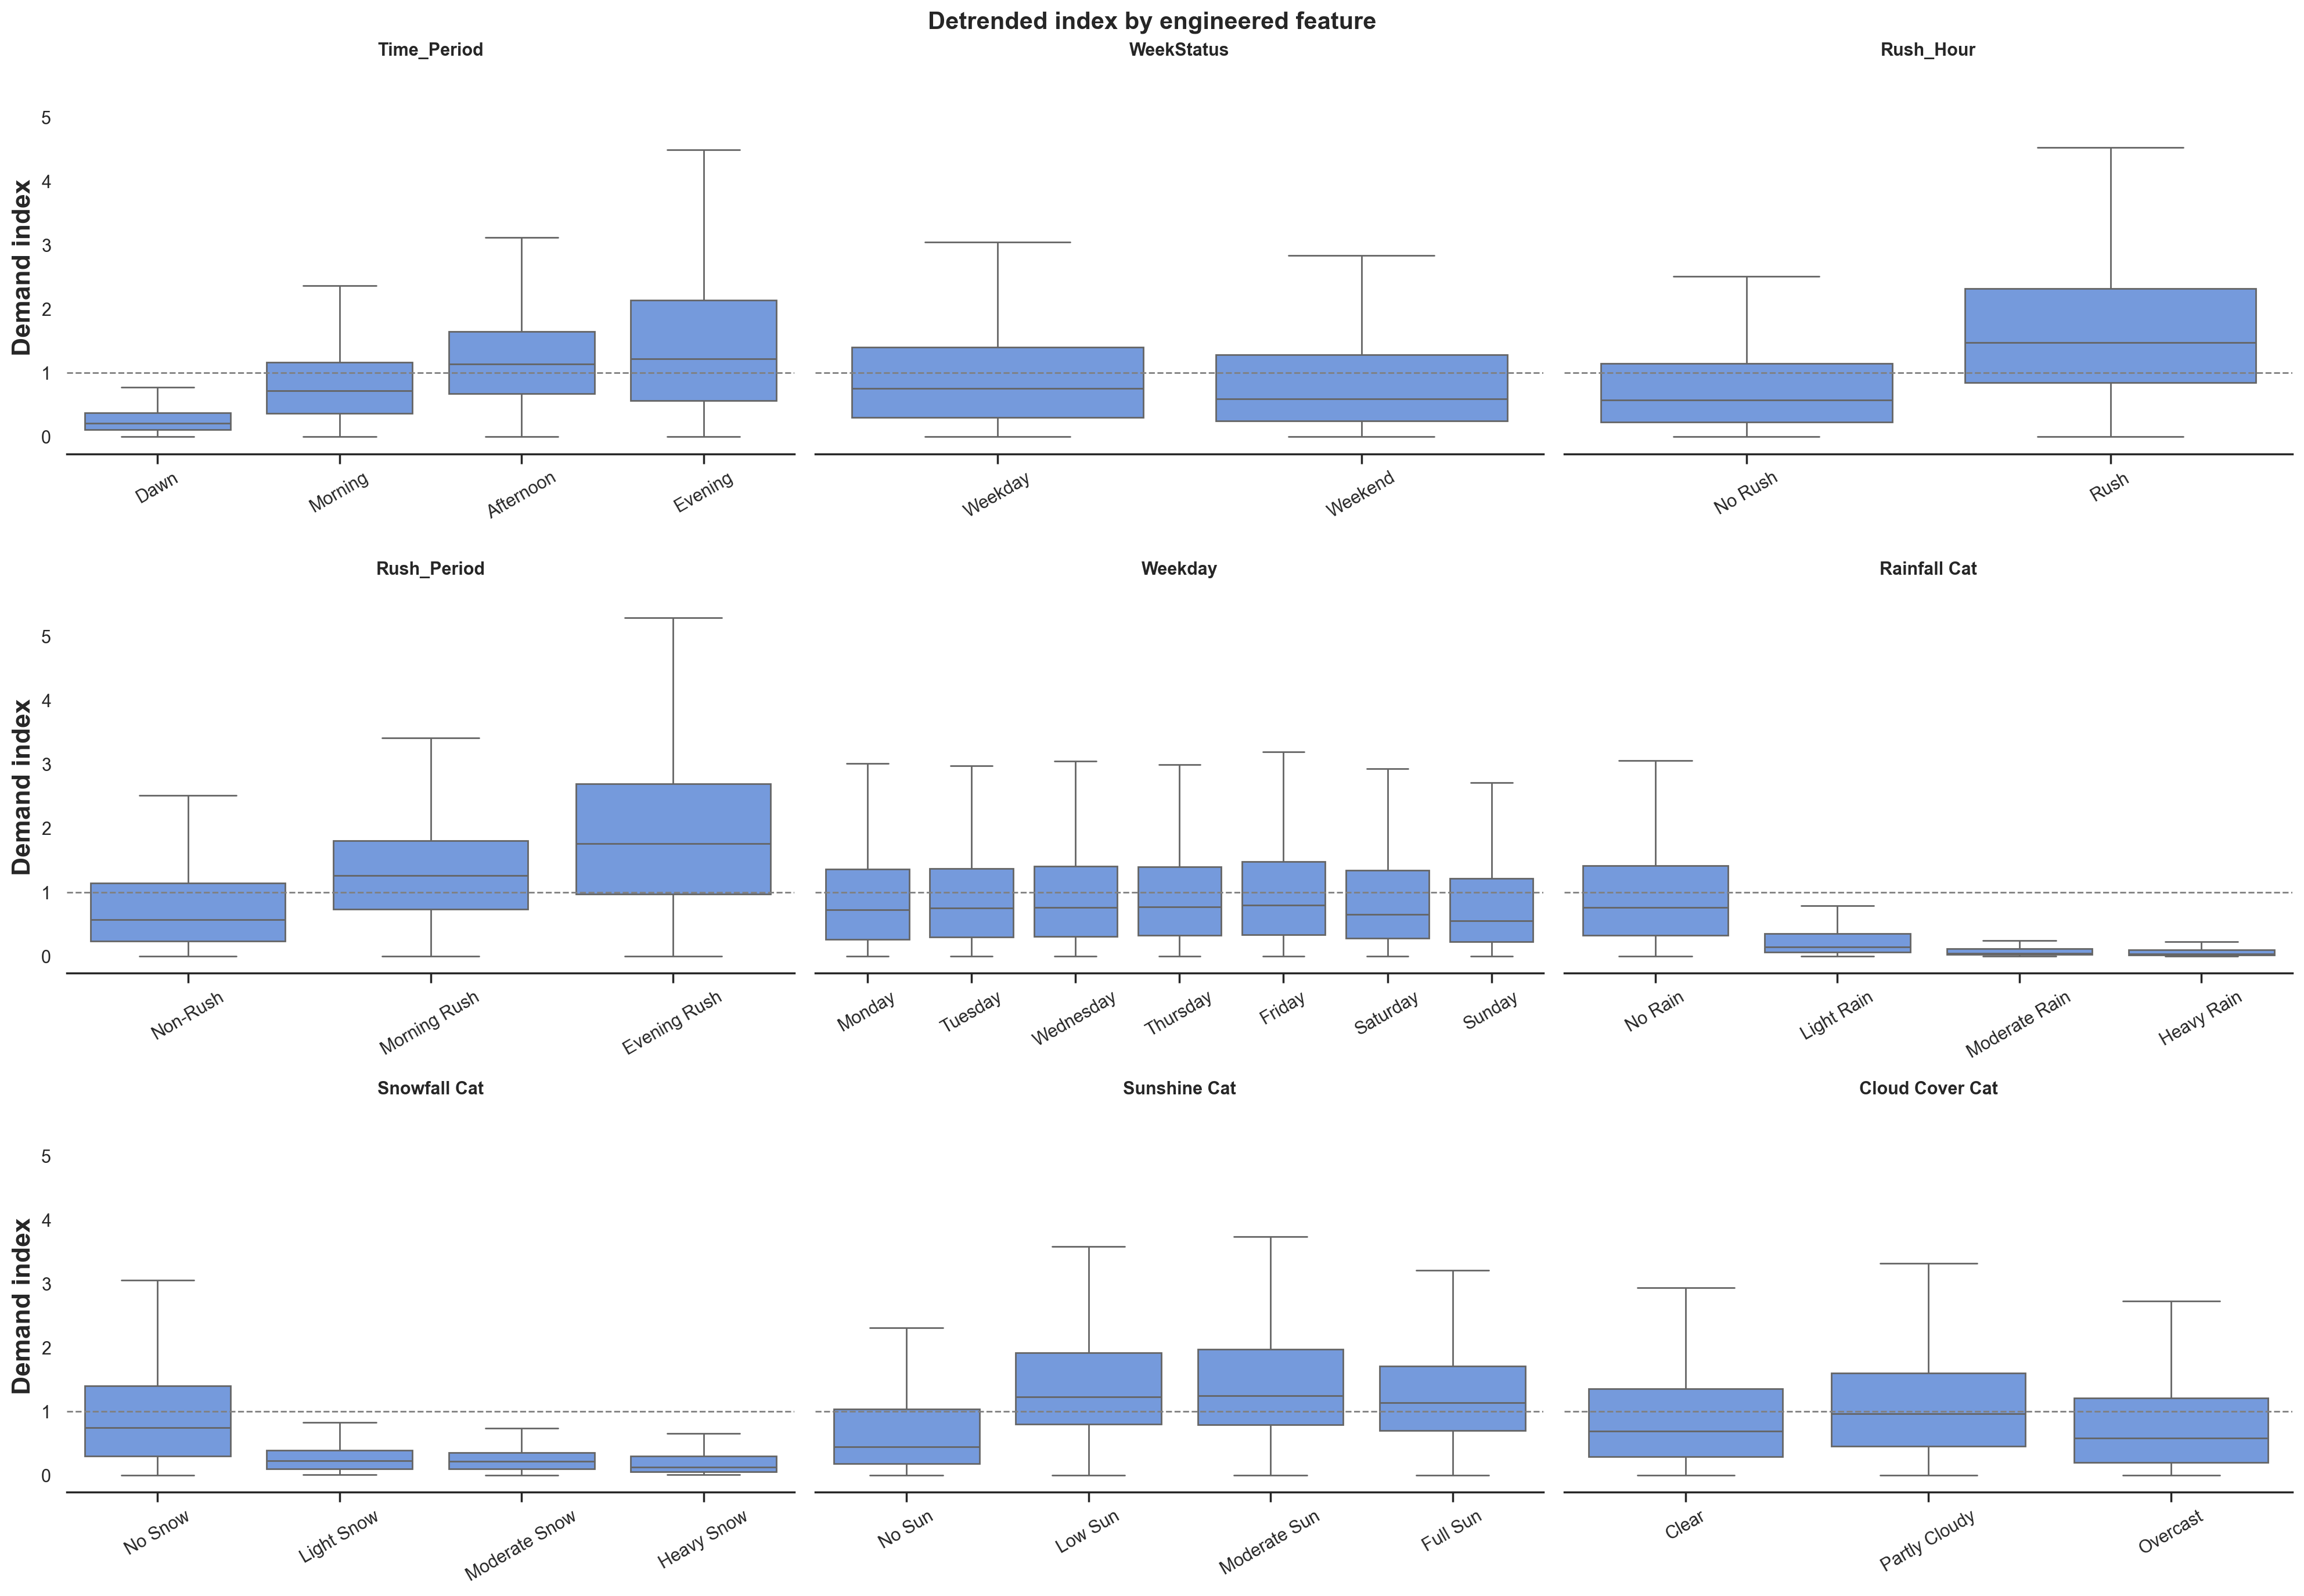

In [7]:
fig, axes = fe.plot_category_boxplots(mv, index_col=INDEX, lang=lang)
plt.show()


In [8]:
effect_summary, category_effects = fe.category_effect_summary(mv, index_col=INDEX, lang=lang)
effect_labels = lang({
    'minimum': 'Valor mínimo',
    'maximum': 'Valor máximo',
    'amplitude': 'Amplitude',
})
display(
    fe.localize_feature_table(effect_summary, lang=lang).style
    .background_gradient(cmap='Blues', subset=[effect_labels['amplitude']])
    .format({
        effect_labels['minimum']: '{:.3f}',
        effect_labels['maximum']: '{:.3f}',
        effect_labels['amplitude']: '{:.3f}',
    })
)


,Variable,Lowest median,Minimum value,Highest median,Maximum value,Range,Smallest n by level
3,Rush_Period,Non-Rush,0.575,Evening Rush,1.763,1.188,6380
0,Time_Period,Dawn,0.210,Evening,1.219,1.008,18716
2,Rush_Hour,No Rush,0.575,Rush,1.475,0.901,14878
7,Sunshine Cat,No Sun,0.447,Moderate Sun,1.244,0.797,3896
5,Rainfall Cat,Heavy Rain,0.040,No Rain,0.766,0.726,331
6,Snowfall Cat,Heavy Snow,0.127,No Snow,0.748,0.621,322
8,Cloud Cover Cat,Overcast,0.588,Partly Cloudy,0.969,0.380,16092
4,Weekday,Sunday,0.550,Friday,0.795,0.245,10740
1,WeekStatus,Weekend,0.599,Weekday,0.762,0.163,21522


>### Insight
>
> The largest descriptive separation was obtained for `Rush_Period`: the median shifted from 0.575 in `Non-Rush` to 1.260 in the morning peak and 1.763 in the afternoon/night peak. When combining the two peaks in `Rush_Hour`, the amplitude was reduced to 0.901. It was thus demonstrated that the new feature preserves a relevant asymmetry that was hidden by the binary representation.
>
> Large median spreads were also observed for `Time_Period` (1.008), `Sunshine Cat` (0.797), `Rainfall Cat` (0.726), and `Snowfall Cat` (0.621). However, the most intense rain and snow levels were represented by only a few hundred observations. These spreads are descriptive and unadjusted, and should not be interpreted as isolated causal effects.
>
> The smallest amplitudes were obtained for `WeekStatus` and `Weekday`. Nevertheless, their manual exclusion was not determined: redundancy with time, day period, and peak will be evaluated by `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector`, and `NoSelector` within each estimator configuration.


### 3.1 Inspection of `MeanEncoder`

The `MeanEncoder`, provided by `feature_engine` and included in the optimizer's search space, implements an unregularized form of *target encoding*. Each level $c$ is replaced by the target mean observed in the fitting set, $\widehat{\mu}_c = n_c^{-1}\sum_{i:X_i=c} y_i$.

The following table is diagnostic only. The encoder is simulated using `Demand_Index`, and seasonal means are added to examine pattern stability. In actual modeling, the target, training period, and therefore the encoded values are different. The `Overall` column must not be interpreted as the definitive mapping supplied to the model.

As the transformation is supervised, the adjustment must be performed within each fold. If the means were calculated before temporal separation, the validation target would be incorporated into the feature itself. The same restriction prevents specific means for the year or season retained from being calculated with their own targets.


In [9]:
mean_encoding_by_season = fe.mean_encoding_by_season(mv, index_col=INDEX, lang=lang)
season_labels = list(lang({
    'winter': 'Inverno',
    'spring': 'Primavera',
    'summer': 'Verão',
    'autumn': 'Outono',
}).values())
encoding_labels = lang({
    'overall': 'Geral',
    'across': 'Amplitude entre estações',
})
display(
    fe.localize_feature_table(mean_encoding_by_season, lang=lang).style
    .background_gradient(
        cmap='RdYlBu_r',
        subset=season_labels + [encoding_labels['overall']],
        axis=None,
    )
    .format({
        col: '{:.3f}'
        for col in season_labels
        + [encoding_labels['overall'], encoding_labels['across']]
    })
    .format({'n': '{:,.0f}'})
)


#### Separation Produced Within Each Season

From the previous reading, the variation of the same level between seasons is measured. The complementary reading below is calculated in the opposite direction: for each season, the amplitude between the levels of a feature is obtained. Thus, it is verified whether the separation capacity remains stable or depends on the seasonal context.


In [10]:
within_season_spread = fe.within_season_spread(mv, index_col=INDEX, lang=lang)
display(
    fe.localize_feature_table(within_season_spread, lang=lang).style
    .background_gradient(cmap='Greens', axis=None)
    .format('{:.3f}')
)


Seasons,Winter,Spring,Summer,Autumn
Variable,,,,
Time_Period,0.463,1.191,1.627,1.497
WeekStatus,0.115,0.113,0.154,0.106
Rush_Hour,0.458,0.966,1.020,1.064
Rush_Period,0.508,1.264,1.329,1.351
Weekday,0.150,0.142,0.278,0.214
Rainfall Cat,0.419,1.027,1.143,1.196
Snowfall Cat,0.309,0.982,0.000,0.896
Sunshine Cat,0.381,0.882,0.675,0.865
Cloud Cover Cat,0.127,0.354,0.371,0.342


In [11]:
verification = fe.meanencoder_verification(
    mv, mean_encoding_by_season, index_col=INDEX, demo_col='Rush_Period', lang=lang)
display(verification.style.format('{:.6f}'))


,Demonstration MeanEncoder,Table overall,Absolute difference
Level,,,
Evening Rush,1.906264,1.906264,0.000000
Morning Rush,1.360941,1.360941,0.000000
Non-Rush,0.799171,0.799171,0.000000


>### Insight
>
> It was verified that `Overall` exactly reproduces the `MeanEncoder` only for the demonstration frame, in which the complete index was used as the target. This equality validates the mechanics of the inspection, but does not represent the values learned within the model folds.
>
> The separation produced by `Rush_Period`, `Time_Period`, and precipitation was much smaller in winter than in the other seasons. This provides evidence of a seasonal interaction that a single global mean cannot represent. Nonlinear estimators or selected interactions may absorb this limitation; season-target means will not be deliberately created outside the folds.
>
> Since the simple mean does not apply smoothing, greater instability may be produced by the rare levels of rain and snow. Therefore, `MeanEncoder` is maintained as an alternative in the search space, alongside regularized and unsupervised encoders, and not as a fixed choice based on this table *in-sample*.


## 4. Meteorological Columns: Sunshine, Cloud Cover, and Ground Temperature

Examined are `Sunshine (hr)`, `Cloud Cover (oktas)`, and `Ground Temp(C)`. For variables with few possible values, relationships are summarized by observed value; for ground temperature, quantiles with similar sizes are used. Median and interquartile range are presented to avoid reducing the association shape to a single mean.

Spearman correlations are used only as a monotonic bivariate measure. Time, month, season, and air temperature are not controlled in this calculation. Consequently, an association between sunshine and demand may simultaneously reflect the presence of daylight, weather conditions, and time of day.


In [12]:
new_weather = ['Sunshine (hr)', 'Cloud Cover (oktas)', 'Ground Temp(C)']
weather_summary = fe.new_weather_summary(mv, new_weather, INDEX, lang=lang)
weather_labels = lang({
    'valid_n': 'n válido',
    'missing': 'Ausentes (%)',
    'skewness': 'Assimetria',
    'spearman': 'Spearman com o índice',
})
display(weather_summary.style.format({
    weather_labels['valid_n']: '{:,.0f}',
    weather_labels['missing']: '{:.2f}',
    weather_labels['skewness']: '{:.3f}',
    weather_labels['spearman']: '{:.3f}',
}))


,valid n,Missing (%),Skewness,Spearman with the index
Variable,,,,
Sunshine (hr),"75,304",0.00,0.991,0.397
Cloud Cover (oktas),"69,836",7.26,-0.043,-0.098
Ground Temp(C),"75,279",0.03,0.439,0.531


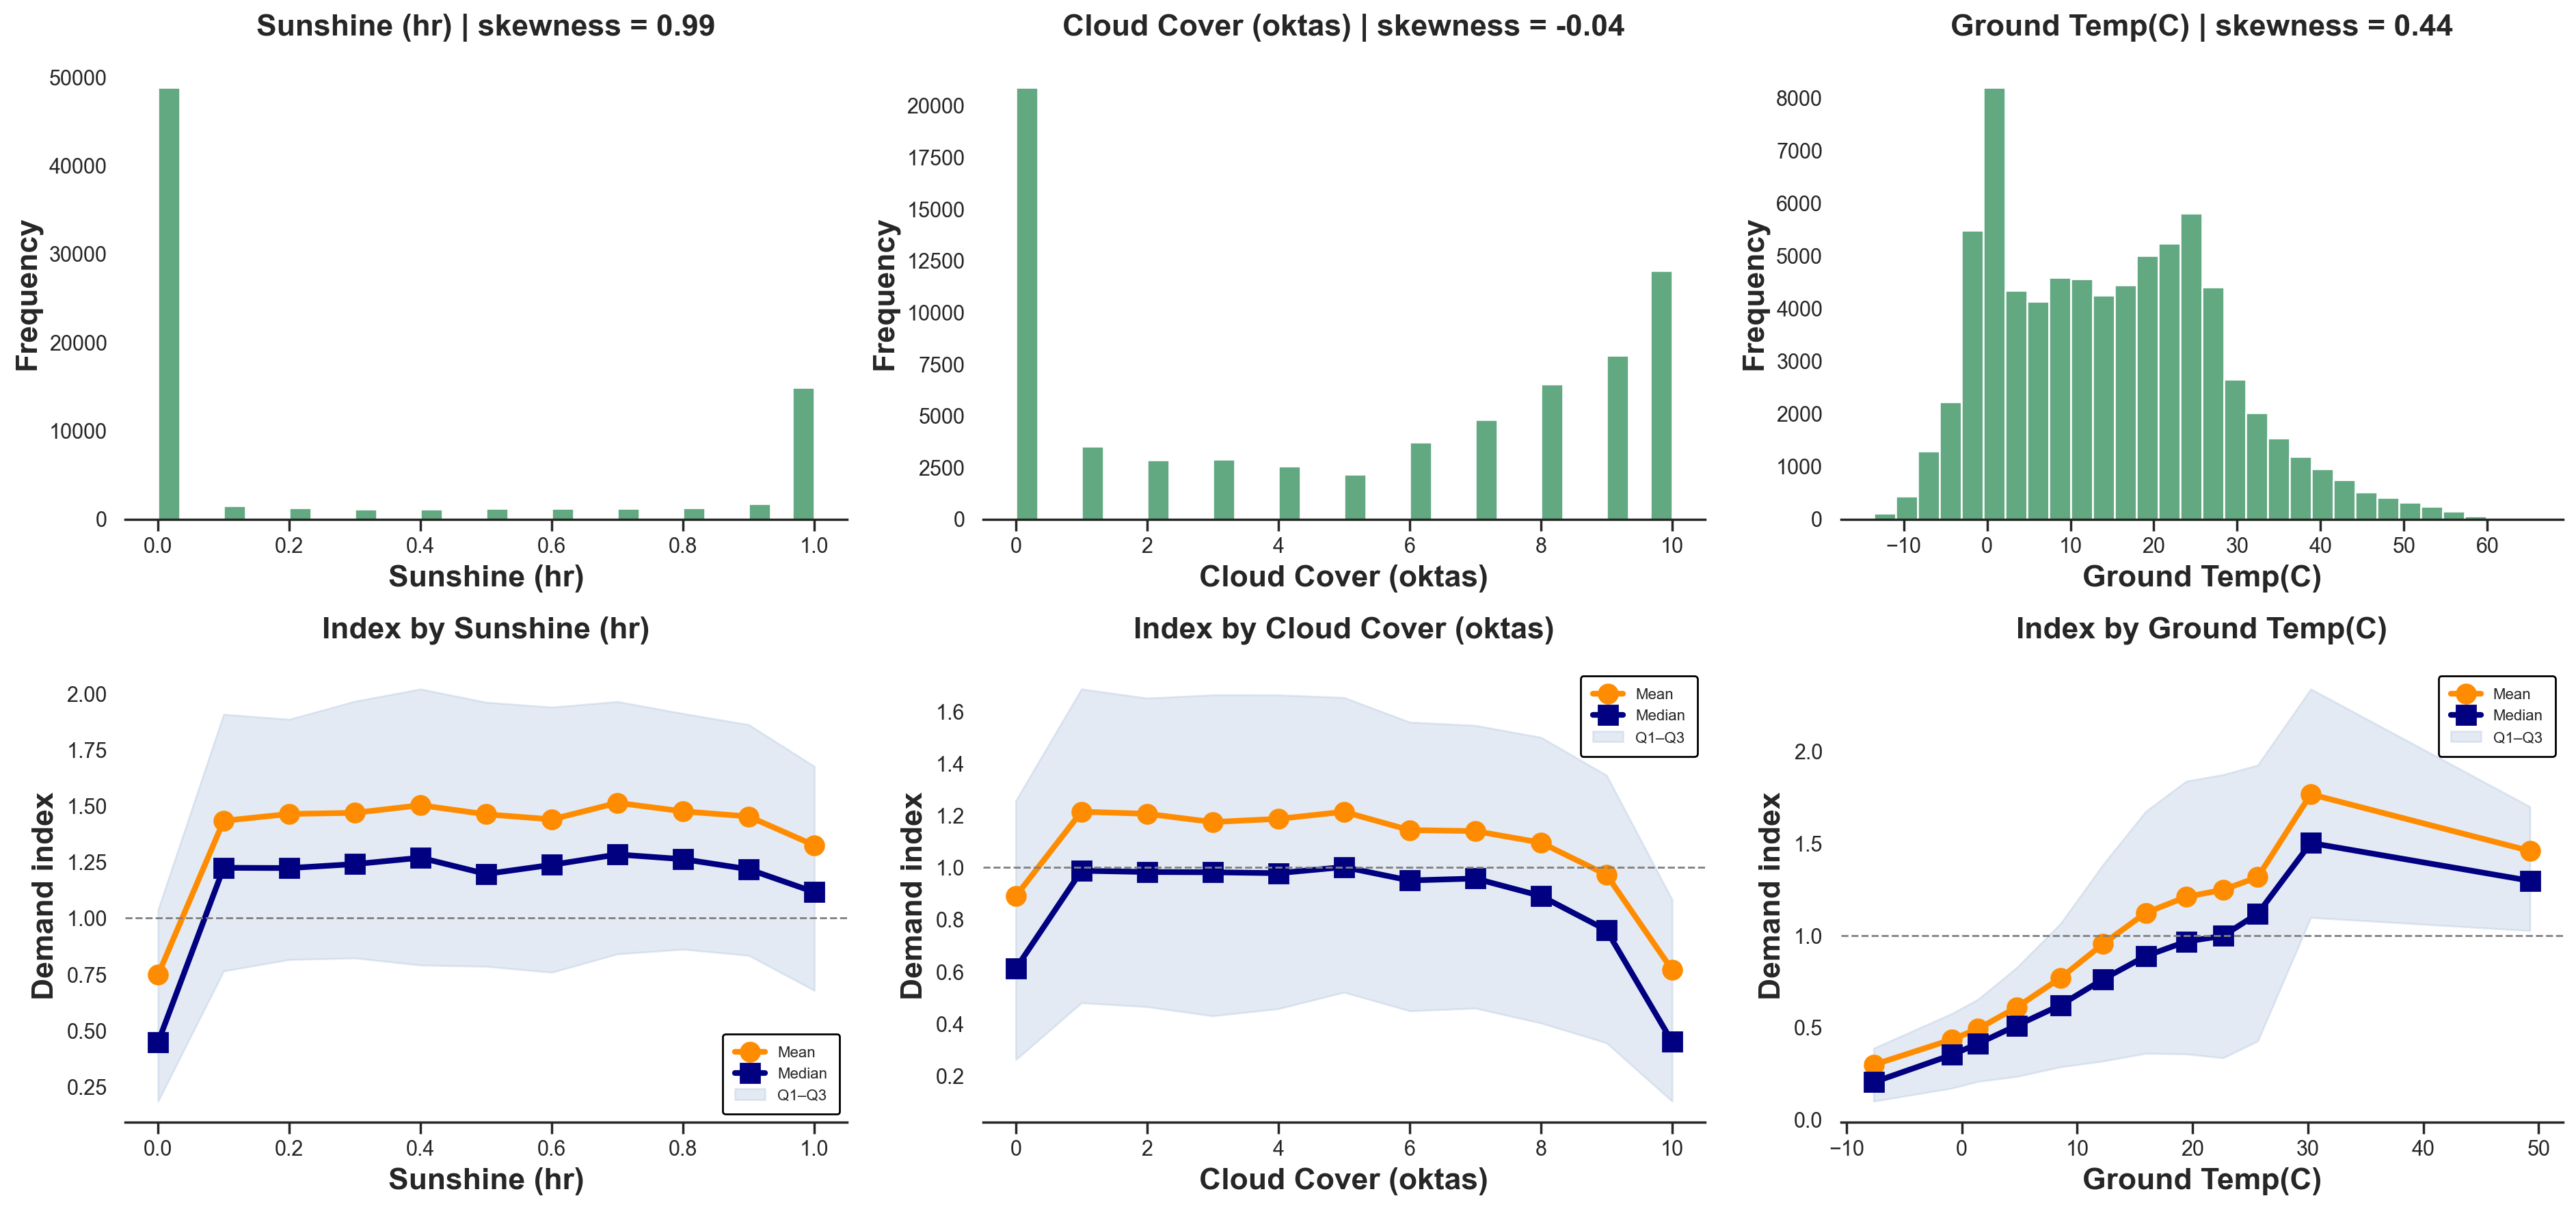

In [13]:
fig, axes = fe.plot_weather_relationships(mv, new_weather, INDEX, lang=lang)
plt.show()


>### Insight
>
> The highest monotonic association with the index was observed for `Ground Temp(C)` (`ρ = 0.531`), followed by `Sunshine (hr)` (`ρ = 0.397`). For `Cloud Cover (oktas)`, the association was weak and negative (`ρ = -0.098`), although non-linear differences between bands may still be explored by flexible models.
>
> In `Cloud Cover (oktas)`, 7.26% of the observations in the analytical frame remained missing. Median imputation was not applied before this EDA, and missing values were not confused with clear or overcast skies. During modeling, any imputation must be learned within the temporal folds.
>
> The thermal relationship should not be interpreted as an independent contribution because strong collinearity among ground temperature, air temperature, and dew point was already identified in Notebook 02. The decision between raw and categorical representations will be left to the selectors and out-of-sample performance.


## 5. Correspondence Between Feature Engineering and the Modeling Space

Not every column created for diagnostics must automatically be supplied to the estimator. Therefore, correspondence with the central `RegressionOptimizer` feature lists is verified below. `Date` is preserved for ordering and temporal splitting; `Year` is not used as a direct predictor, preventing chronological identity from becoming a shortcut for the operation's rising demand level.

`Sunshine Cat` and `Cloud Cover Cat` remain descriptive representations in this version of the search space. The first is nearly deterministic relative to continuous sunshine, while the second has substantial missingness. Their eventual inclusion must be explicitly compared and temporally validated rather than inferred from boxplots alone.


In [14]:
feature_audit = fe.feature_model_audit(df, lang=lang)
display(feature_audit)

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='IProgress not found.*')
    from src.optimizer import RegressionOptimizer

model_features = set(RegressionOptimizer._NUMERICAL_FEATURES) | set(
    RegressionOptimizer._CATEGORICAL_FEATURES)
assert 'Rush_Period' in set(RegressionOptimizer._CATEGORICAL_FEATURES)
assert not ({'Date', 'Year'} & model_features)


,Engineered feature,Derived from,Available in the base model,Role
0,Date,DateTime + Hour,No,Temporal ordering and validation
1,Time_Period,Hour,Yes,Candidate for the optimizer's feature selectors
2,Weekday,Date,Yes,Candidate for the optimizer's feature selectors
3,DayNumberOnWeek,Date,Yes,Candidate for the optimizer's feature selectors
4,WeekStatus,Date,Yes,Candidate for the optimizer's feature selectors
5,Rush_Hour,Hour + WeekStatus + Holiday + Functioning Day,Yes,Candidate for the optimizer's feature selectors
6,Rush_Period,Hour + WeekStatus + Holiday + Functioning Day,Yes,Candidate for the optimizer's feature selectors
7,Rainfall Cat,Rainfall(mm),Yes,Candidate for the optimizer's feature selectors
8,Snowfall Cat,Snowfall (cm),Yes,Candidate for the optimizer's feature selectors
9,Sunshine Cat,Sunshine (hr),No,EDA; candidate for future comparison


>### Insight
>
> The integration of `Rush_Period` into the optimizer's categorical feature set has been confirmed. Its final retention is not imposed: it will be compared with `Rush_Hour`, `Time_Period`, `Hour`, and the remaining features by the selectors configured for each estimator.
>
> `Date` and `Year` were kept out of the base predictive feature space. The first column preserves temporal structure, while the second could act as an identifier of historical growth and produce apparent performance without ensuring extrapolation to future years.
>
> The new meteorological categories were kept in the EDA as alternative representations. As high dependence was observed between continuous variables and their discretizations in notebook 02, their automatic inclusion would only duplicate information before a controlled comparison.


## 6. Synthesis

The feature engineering stage was reevaluated alongside the pipeline code. Thirteen engineered features were confirmed, missing values remained explicit in the EDA, and raw demand was no longer overwritten by the detrended index. Separating `Rented Bike Count` from `Demand_Index` clarified the boundary between the operational target and the retrospective measure used for comparison.

A semantic error was corrected in `Rush_Hour`: operating status had been interpreted as a weekday indicator, allowing weekends to be classified as peak periods. The revised rule requires a weekday, active operation, and no holiday. `Rush_Period` was also created to separate morning from afternoon/evening peaks, and it produced the largest median spread among the categorical features analyzed.

The index based on the centered moving average was maintained only for EDA. The transformation removed the growth of approximately 106.8 times between the extreme years without erasing the monthly seasonality, but it cannot be used as a prediction feature because it consults the future. The anomalous months from May to December 2020 were excluded only from the baseline estimation and remained in the analyzed frame.

In the categorical analysis, the largest separation was observed for `Rush_Period`, `Time_Period`, `Rush_Hour`, sunshine, and precipitation. The rarity of intense rain and snow bands and the interaction of effects with season prevented these spreads from being treated as adjusted feature importance. The `MeanEncoder` inspection demonstrated the mechanical equivalence of the mean by level while also making explicit the leakage risk and instability of unregularized means in small groups.

Among the new meteorological measurements, the strongest monotonic associations were observed for ground temperature and sunshine. However, thermal collinearity and confounding with hour and season remained. Therefore, no manual exclusions were imposed from this EDA. The choice will be made within temporal validation by `SelectKBest`, `RFE`, `SelectFromModel`, `SequentialFeatureSelector`, and `NoSelector`, conditional on the estimator and transformation under evaluation.

### Methodological References

Micci-Barreca, D. (2001). *A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems*. **ACM SIGKDD Explorations Newsletter, 3**(1), 27–32. https://doi.org/10.1145/507533.507538

Miller, D. M., & Williams, D. (2003). *Shrinkage estimators of time series seasonal factors and their effect on forecasting accuracy*. **International Journal of Forecasting, 19**(4), 669–684. https://doi.org/10.1016/S0169-2070(02)00077-8
